In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#### Basic Graph

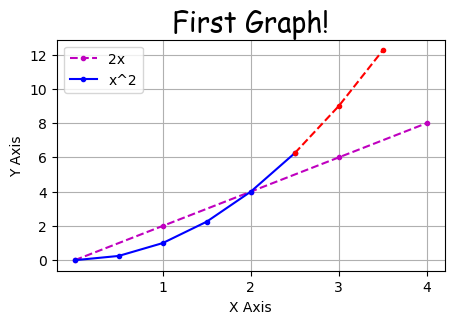

In [479]:
x = [0,1,2,3,4]
y = [0,2,4,6,8]

#Resize your graph
plt.figure(figsize=[5,3], dpi=100)

#plt.plot(x,y, label='2x', color='red', linewidth='2', marker='.', linestyle='--', markersize=10, markeredgecolor='blue')
plt.plot(x,y, 'm.--', label='2x')

x2 = np.arange(0,4, 0.5)
plt.plot(x2[:6], x2[:6]**2, 'b.-', label='x^2')
plt.plot(x2[5:], x2[5:]**2, 'r.--')

plt.title("First Graph!", fontdict={'fontname': 'Comic Sans MS', 'fontsize': 20})
plt.xlabel('X Axis')
plt.ylabel('Y Axis')

plt.xticks([1,2,3,4])
#plt.yticks([0,2,4,6,8,10])
plt.legend()
plt.grid(True)

plt.savefig('mygraph.png', dpi=100)

plt.show()

#### Bar Chart

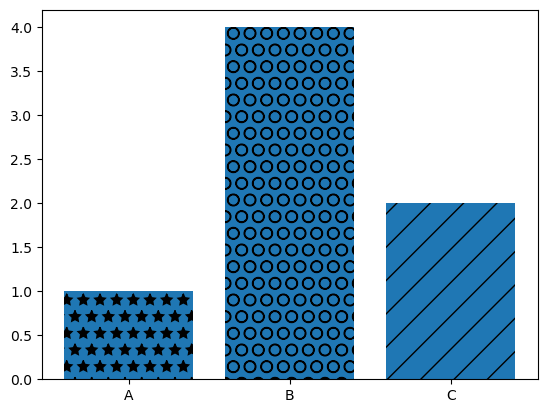

<Figure size 600x400 with 0 Axes>

In [155]:
labels = ['A', 'B', 'C']
values = [1,4,2]

bars = plt.bar(labels, values)

patterns = ['/', 'O', '*']
for bar in bars:
    bar.set_hatch(patterns.pop())


#bars[0].set_hatch('/')
#bars[1].set_hatch('o')
#bars[2].set_hatch('*')

plt.figure(figsize=(6,4))

plt.show()

#### Line Graph with gas_prices data

0     1990
3     1993
6     1996
9     1999
12    2002
15    2005
18    2008
Name: Year, dtype: int64


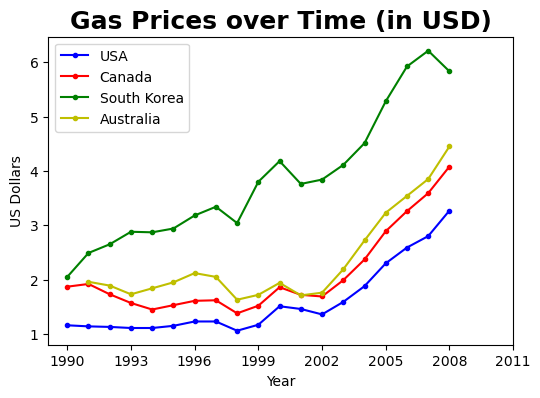

In [284]:
gas = pd.read_csv('/Users/mr.tian/Desktop/gas_prices.csv')

plt.figure(figsize=(6,4))

plt.title("Gas Prices over Time (in USD)", fontdict={'fontweight': 'bold', 'fontsize': 18})

plt.plot(gas.Year, gas.USA, 'b.-', label='USA')
plt.plot(gas.Year, gas.Canada, 'r.-', label = 'Canada')
plt.plot(gas.Year, gas['South Korea'], 'g.-', label = 'South Korea')
plt.plot(gas.Year, gas.Australia, 'y.-', label='Australia')

#Another way to plot many values
#countries_to_look_at = ['Australia', 'USA', 'Canada', 'South Korea']
#for country in gas:
#    if country in countries_to_look_at:
#        plt.plot(gas.Year, gas[country], marker='.', label = country)

print(gas.Year[::3])

plt.xticks(gas.Year[::3].tolist()+[2011])

plt.xlabel('Year')
plt.ylabel('US Dollars')

plt.legend()

plt.savefig('Gas_Price_figure.png', dpi=300)

plt.show()

#### Load FIFA data

In [287]:
fifa = pd.read_csv('/Users/mr.tian/Desktop/fifa_data.csv')

In [294]:
fifa.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


#### Higtograms

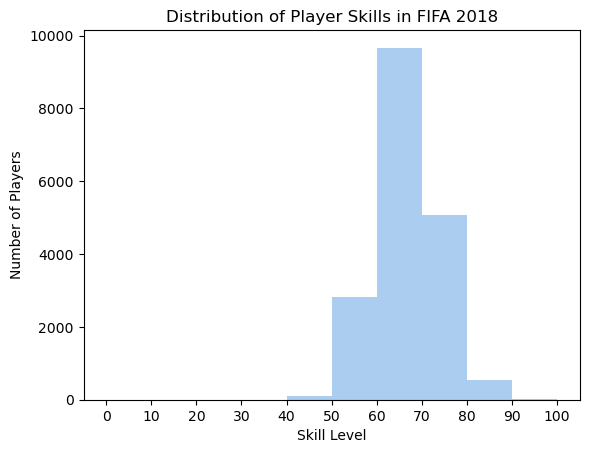

In [318]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

plt.hist(fifa.Overall, bins=bins, color='#abcdef')

plt.xticks(bins)
plt.ylabel('Number of Players')
plt.xlabel('Skill Level')
plt.title('Distribution of Player Skills in FIFA 2018')


plt.show()

#### Pie Charts

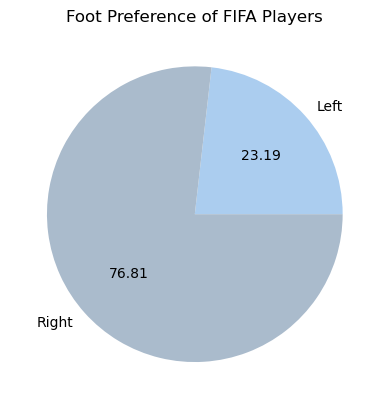

In [357]:
left = fifa.loc[fifa['Preferred Foot'] == 'Left'].count().iloc[0]
right = fifa.loc[fifa['Preferred Foot'] == 'Right'].count().iloc[0]

labels = ['Left', 'Right']
colors = ['#abcdef', '#aabbcc']

plt.pie([left, right], labels = labels, colors = colors, autopct='%.2f')

plt.title('Foot Preference of FIFA Players')

plt.show()

In [387]:
def weight(row):
    if row.Weight < 60:
        return 'light'
    elif 60 <= row.Weight < 70:
        return 'light_medium'
    elif 70 <= row.Weight < 75:
        return 'medium'
    elif 75 <= row.Weight < 80:
        return 'medium_heavy'
    else:
        return 'heavy'


fifa['Weight_Class'] = fifa.apply(weight, axis=1)

In [389]:
print(fifa[['Weight', 'Weight_Class']].head(10))

      Weight  Weight_Class
0  72.121128        medium
1  83.007336         heavy
2  68.038800  light_medium
3  76.203456  medium_heavy
4  69.853168  light_medium
5  73.935496        medium
6  66.224432  light_medium
7  86.182480         heavy
8  82.100152         heavy
9  87.089664         heavy


In [397]:
counts = fifa['Weight_Class'].value_counts()

light = counts['light']
light_medium = counts['light_medium']
medium = counts['medium']
medium_heavy = counts['medium_heavy']
heavy = counts['heavy']

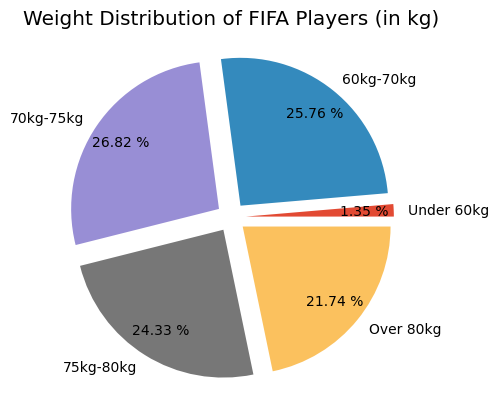

In [427]:
weights = [light, light_medium, medium, medium_heavy, heavy]

plt.style.use('ggplot')

labels = ['Under 60kg', '60kg-70kg', '70kg-75kg', '75kg-80kg', 'Over 80kg']
explode = (.1,.1,.1,.1,.1)

plt.title('Weight Distribution of FIFA Players (in kg)')

plt.pie(weights, labels = labels, autopct='%.2f %%', pctdistance=0.8, explode=explode)
plt.show()

In [429]:
fifa

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,Weight_Class
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M,medium
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M,heavy
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M,light_medium
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M,medium_heavy
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M,light_medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,18202,238813,J. Lundstram,19,https://cdn.sofifa.org/players/4/19/238813.png,England,https://cdn.sofifa.org/flags/14.png,47,65,Crewe Alexandra,...,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,€143K,light_medium
18203,18203,243165,N. Christoffersson,19,https://cdn.sofifa.org/players/4/19/243165.png,Sweden,https://cdn.sofifa.org/flags/46.png,47,63,Trelleborgs FF,...,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,€113K,medium_heavy
18204,18204,241638,B. Worman,16,https://cdn.sofifa.org/players/4/19/241638.png,England,https://cdn.sofifa.org/flags/14.png,47,67,Cambridge United,...,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,€165K,light_medium
18205,18205,246268,D. Walker-Rice,17,https://cdn.sofifa.org/players/4/19/246268.png,England,https://cdn.sofifa.org/flags/14.png,47,66,Tranmere Rovers,...,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,€143K,light_medium


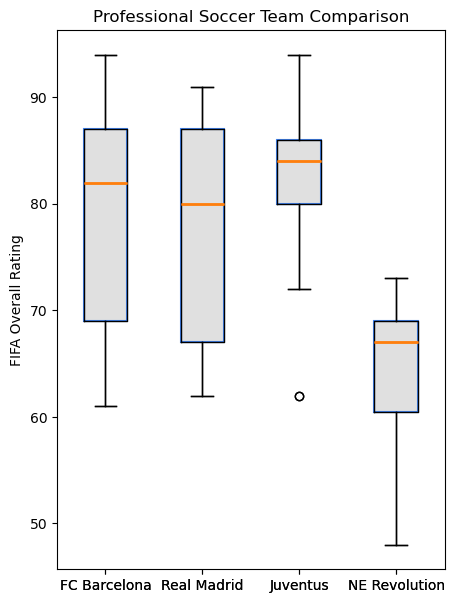

In [475]:
plt.style.use('default')

plt.figure(figsize=(5,7))

barcelona = fifa.loc[fifa.Club == 'FC Barcelona']['Overall']
madrid = fifa.loc[fifa.Club == 'Real Madrid']['Overall']
juventus = fifa.loc[fifa.Club == 'Juventus']['Overall']
revs = fifa.loc[fifa.Club == 'New England Revolution']['Overall']

labels = ['FC Barcelona', 'Real Madrid', 'Juventus', 'NE Revolution']

boxes = plt.boxplot([barcelona, madrid, juventus, revs], labels=labels, patch_artist=True, medianprops={'linewidth':2})

for box in boxes['boxes']:
    # Set edge color
    box.set(color='#4286f4', linewidth=1.5)

    # Change Fill Color
    box.set(facecolor='#e0e0e0')

plt.boxplot([barcelona, madrid, juventus, revs], labels = labels)

plt.title('Professional Soccer Team Comparison')
plt.ylabel('FIFA Overall Rating')

plt.show()

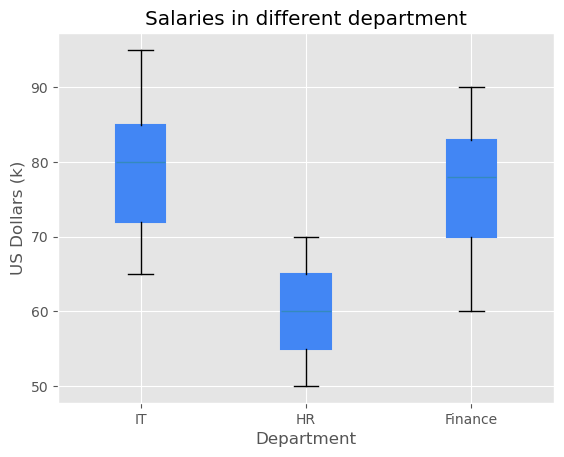

In [610]:
IT = np.array([65, 70, 72, 75, 80, 82, 85, 90, 95])
HR = np.array([50, 52, 55, 58, 60, 62, 65, 68, 70])
Finance = np.array([60, 65, 70, 75, 78, 80, 83, 85, 90])

labels = ['IT', 'HR', 'Finance']
boxes = plt.boxplot([IT, HR, Finance], labels = labels, patch_artist=True)
for box in boxes['boxes']:
    box.set(color='#4286f4', linewidth=1.5)

plt.title('Salaries in different department')
plt.xlabel('Department')
plt.ylabel('US Dollars (k)')
plt.show()

#### Practice

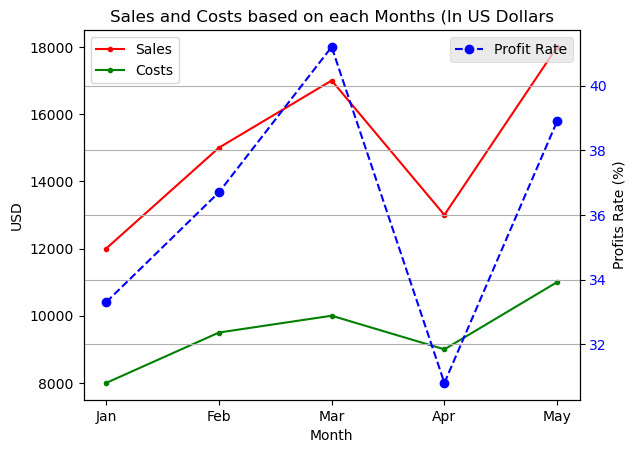

In [540]:

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
sales = [12000, 15000, 17000, 13000, 18000]
costs = [8000, 9500, 10000, 9000, 11000]
profits_rate = [33.3, 36.7, 41.2, 30.8, 38.9]

fig, ax1 = plt.subplots()

plt.title('Sales and Costs based on each Months (In US Dollars')
ax1.set_xlabel('Month')
ax1.set_ylabel('USD')

ax1.plot(months, sales, 'r.-', label='Sales')
ax1.plot(months, costs, 'g.-' ,label='Costs')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.plot(months, profits_rate, 'b--o', label='Profit Rate')
ax2.set_ylabel('Profits Rate (%)')
ax2.tick_params(axis='y', labelcolor='blue')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.style.use('ggplot')
plt.legend()
plt.grid(True)

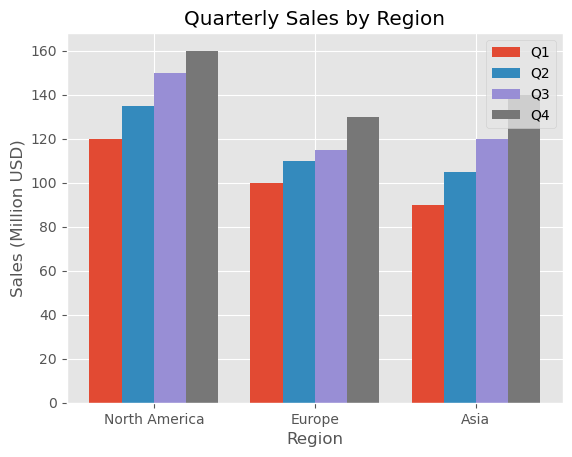

In [562]:
region = ['North America', 'Europe', 'Asia']
Q1 = np.array([120, 100, 90])
Q2 = np.array([135, 110, 105])
Q3 = np.array([150, 115, 120])
Q4 = np.array([160, 130, 140])

x = np.arange(len(region))  # 3 个位置：每个地区一个
w = 0.2                     # 柱宽

plt.bar(x - 1.5*w, Q1, width=w, label='Q1')
plt.bar(x - 0.5*w, Q2, width=w, label='Q2')
plt.bar(x + 0.5*w, Q3, width=w, label='Q3')
plt.bar(x + 1.5*w, Q4, width=w, label='Q4')

plt.xticks(x, region)
plt.xlabel('Region')
plt.ylabel('Sales (Million USD)')
plt.title('Quarterly Sales by Region')
plt.legend()
plt.show()

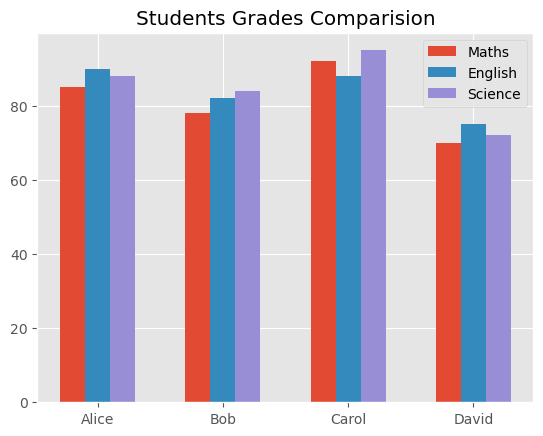

In [604]:
students = ['Alice', 'Bob', 'Carol', 'David']
maths = np.array([85,78,92,70])
english = np.array([90,82,88,75])
science = np.array([88,84,95,72])

x = np.arange(len(students))
width = 0.2

plt.title('Students Grades Comparision')

plt.bar(x - w, maths, width=width, label='Maths')
plt.bar(x, english, width=width, label = 'English')
plt.bar(x + w, science, width=width, label = 'Science')

plt.xticks(x, students)
plt.legend()
plt.grid(True)
plt.show()
